# Module 04: Embeddings

## Introduction

Converting token IDs into dense vectors. Embeddings give meaning to
numbers - similar tokens end up close together in vector space.

**Embeddings** are learned vector representations. Instead of treating
token ID 42 as just the number 42, we give it a rich vector like
`[0.2, -0.5, 0.8, ...]` that captures its meaning.

Why embeddings matter for LLMs:

-   **Similarity**: Similar words have similar vectors (“cat” and “dog”
    are close)
-   **Composition**: Vectors can be combined meaningfully
-   **Learning**: The model learns these representations during training
-   **Position**: We also embed WHERE tokens are in the sequence

Two types of embeddings in transformers:

1.  **Token embeddings**: What the token means
2.  **Positional embeddings**: Where the token is in the sequence

### Memory and Scale Considerations

Embeddings are often the largest single component of a language model.
The parameter count is simply `vocab_size x embed_dim`:

| Model       | Vocab Size | Embed Dim | Embedding Params | Memory (fp32) |
|-------------|------------|-----------|------------------|---------------|
| GPT-2 Small | 50,257     | 768       | 38.6M            | 147 MB        |
| LLaMA 7B    | 32,000     | 4,096     | 131M             | 500 MB        |
| LLaMA 70B   | 32,000     | 8,192     | 262M             | 1 GB          |

This is why vocabulary size is a critical design decision. A larger
vocabulary means each token carries more information (fewer tokens per
text), but the embedding table grows proportionally.

## Intuition: Coordinates in Meaning Space

Think of embeddings as coordinates in “meaning space”:

    Token: "cat"  -> [0.8, 0.1, 0.9, ...]   <- captures "animal", "pet", etc.
    Token: "dog"  -> [0.7, 0.2, 0.8, ...]   <- similar to cat
    Token: "code" -> [0.1, 0.9, 0.2, ...]   <- very different

    Distance("cat", "dog") < Distance("cat", "code")

Positional embeddings add “where in the sequence” information:

    Position 0: [1.0, 0.0, 0.5, ...]   <- "I'm first"
    Position 1: [0.9, 0.1, 0.4, ...]   <- "I'm second"
    Position 2: [0.8, 0.2, 0.3, ...]   <- "I'm third"

The model combines both:

    Final embedding = Token embedding + Positional embedding

## Embedding Architecture

Here’s how embeddings work in a transformer:

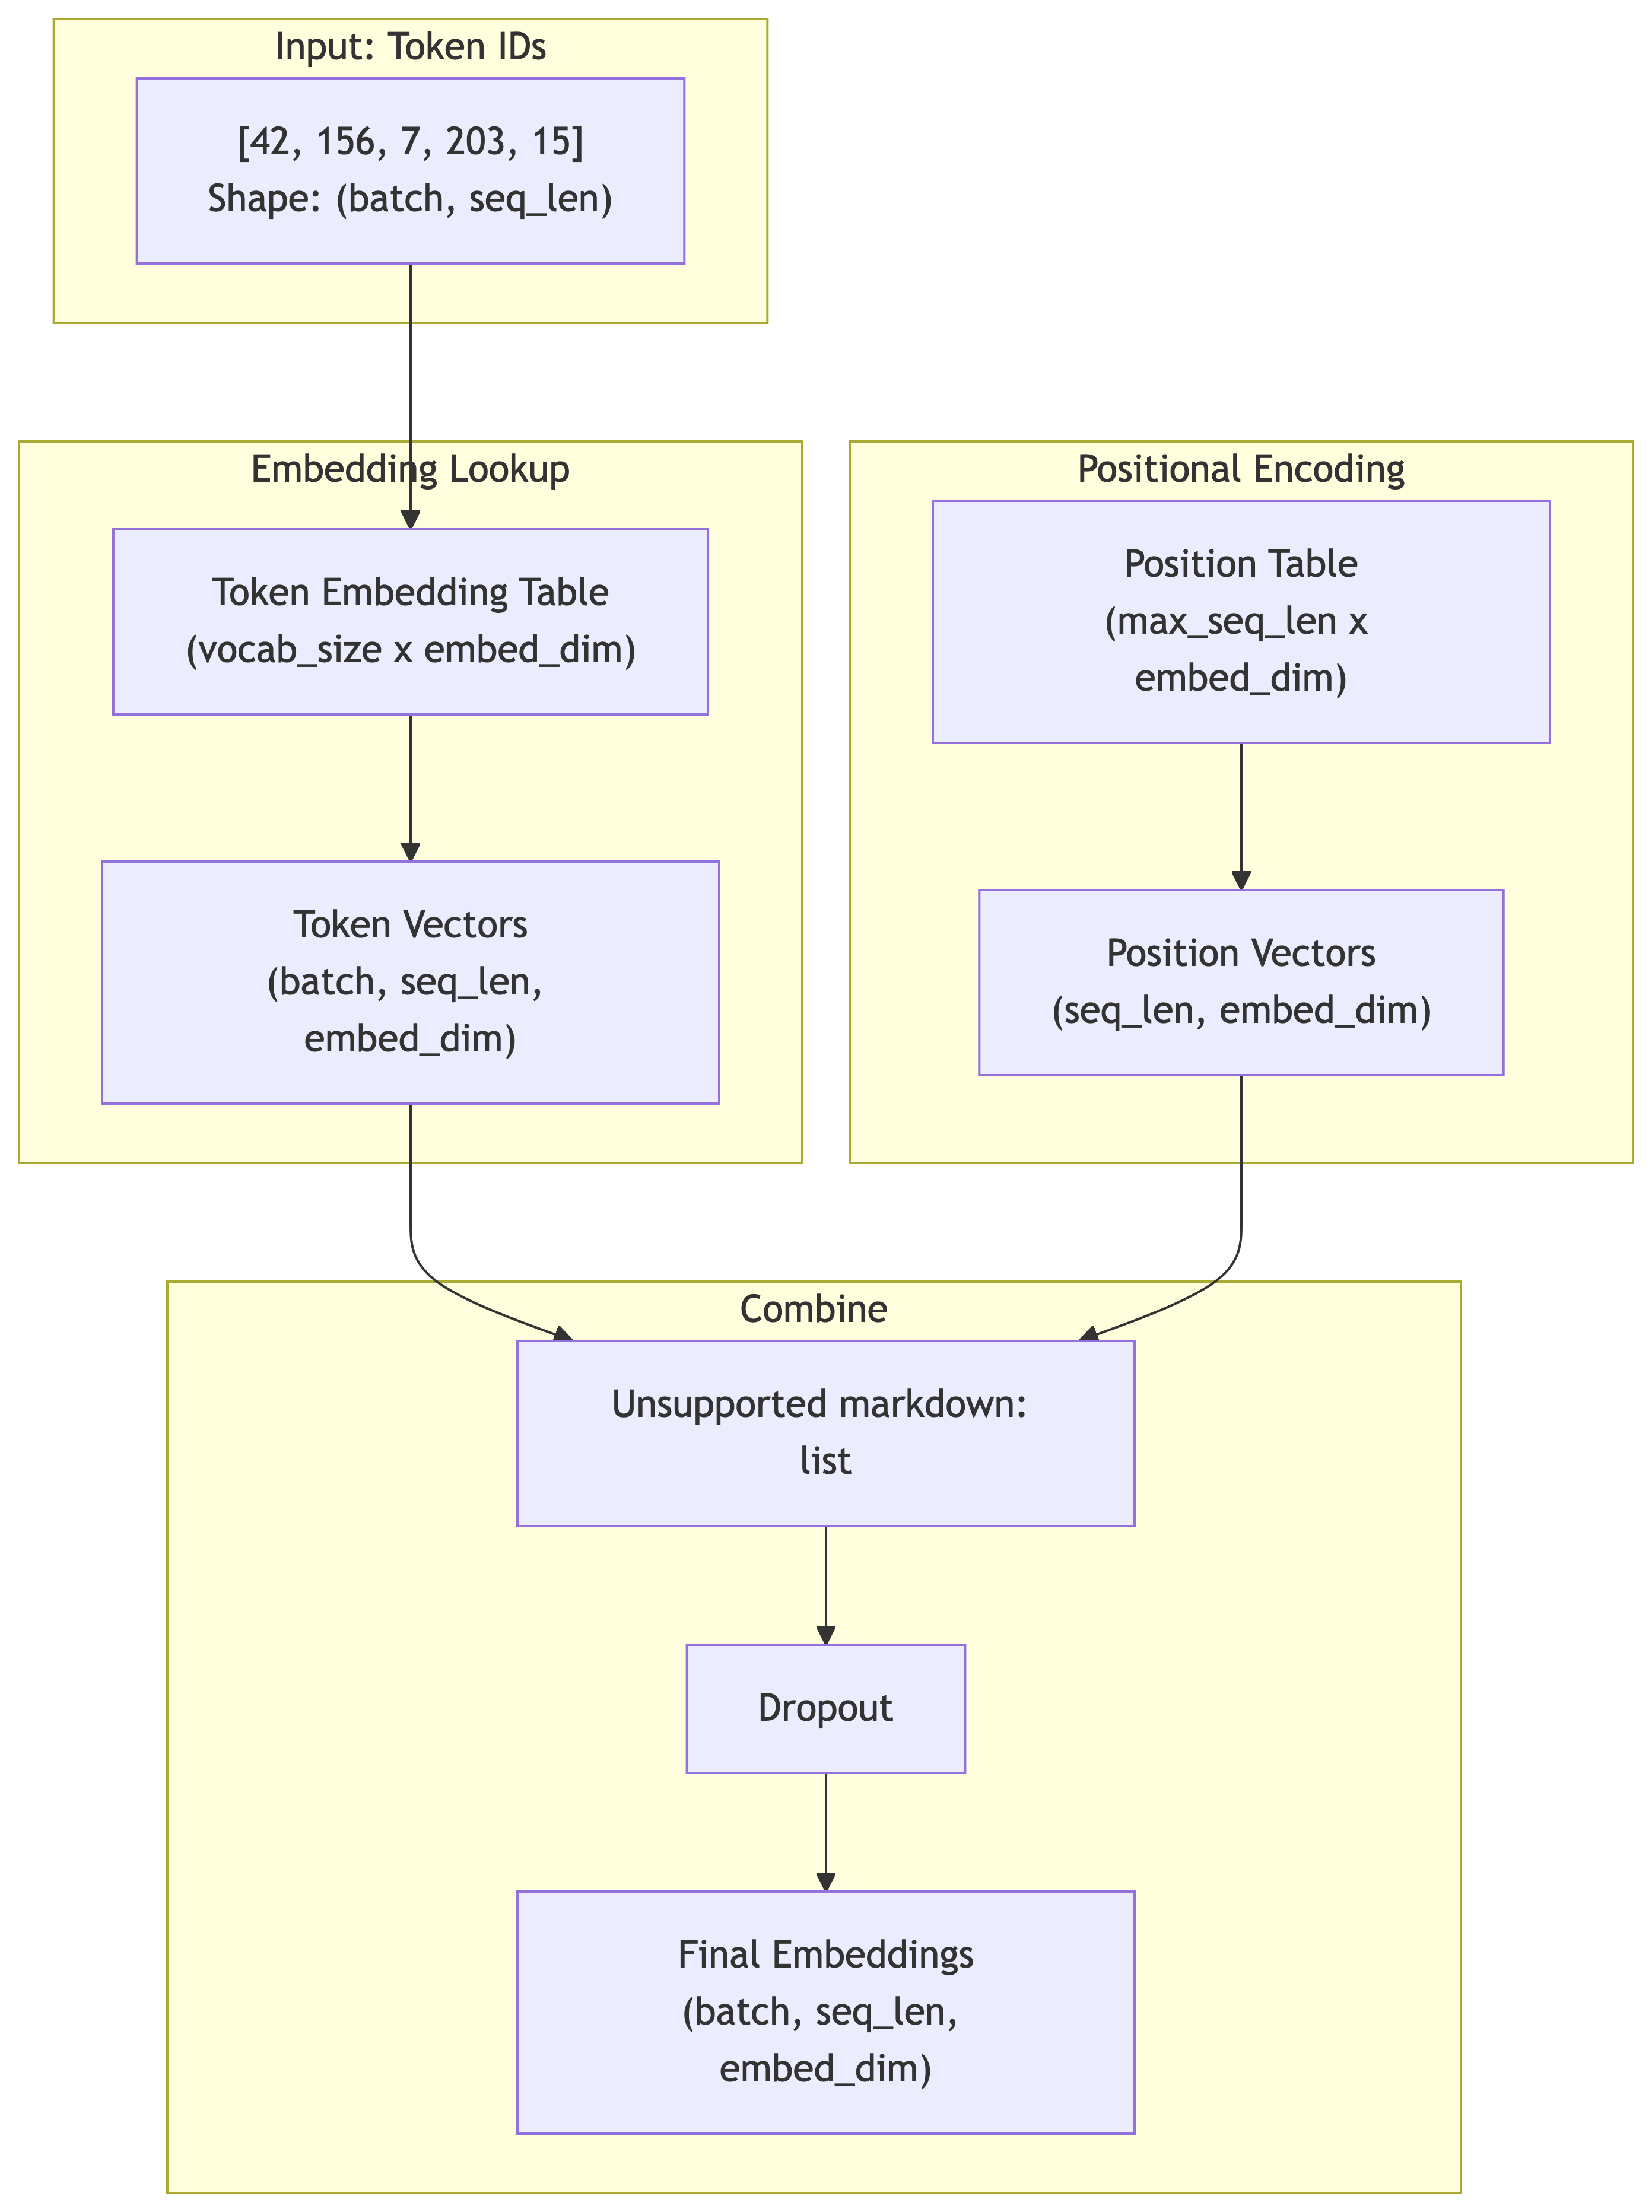

## The Math

### Token Embeddings

Simple lookup table: `E[token_id] = embedding_vector`

``` python
# Embedding table: (vocab_size, embed_dim)
E = torch.randn(vocab_size, embed_dim)

# Look up embeddings for token IDs
token_ids = [5, 23, 42]
embeddings = E[token_ids]  # Shape: (3, embed_dim)
```

### Positional Embeddings

There are several approaches to encoding position:

**1. Learned positional embeddings (GPT-2, BERT):**

``` python
# Position table: (max_seq_len, embed_dim)
P = torch.randn(max_seq_len, embed_dim)
positions = P[:seq_len]  # Get positions for current sequence
```

Each position gets a trainable vector. Simple and effective, but cannot
generalize to positions beyond `max_seq_len`.

**2. Sinusoidal positional embeddings (original Transformer):**

    PE(pos, 2i)   = sin(pos / 10000^(2i/d))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d))

This creates a unique pattern for each position using waves of different
frequencies. The key insight: `PE(pos+k)` can be represented as a linear
function of `PE(pos)`, allowing the model to learn relative positions.

**3. Rotary Position Embedding - RoPE (LLaMA, Mistral):** Rather than
adding position embeddings to token embeddings, RoPE rotates the query
and key vectors based on position. The rotation angle depends on both
position and dimension, encoding relative positions naturally in the
attention computation. This approach extrapolates well to longer
sequences than seen during training.

**4. ALiBi - Attention with Linear Biases (BLOOM):** Instead of adding
position information to embeddings, ALiBi adds a position-dependent bias
directly to the attention scores: closer tokens get higher scores. This
is applied during attention, not in the embedding layer.

### Combined Embeddings

``` python
# Input: token_ids of shape (batch, seq_len)
token_emb = token_embedding[token_ids]     # (batch, seq_len, embed_dim)
pos_emb = position_embedding[:seq_len]      # (seq_len, embed_dim)
x = token_emb + pos_emb                     # (batch, seq_len, embed_dim)
```

## Same Token, Different Positions

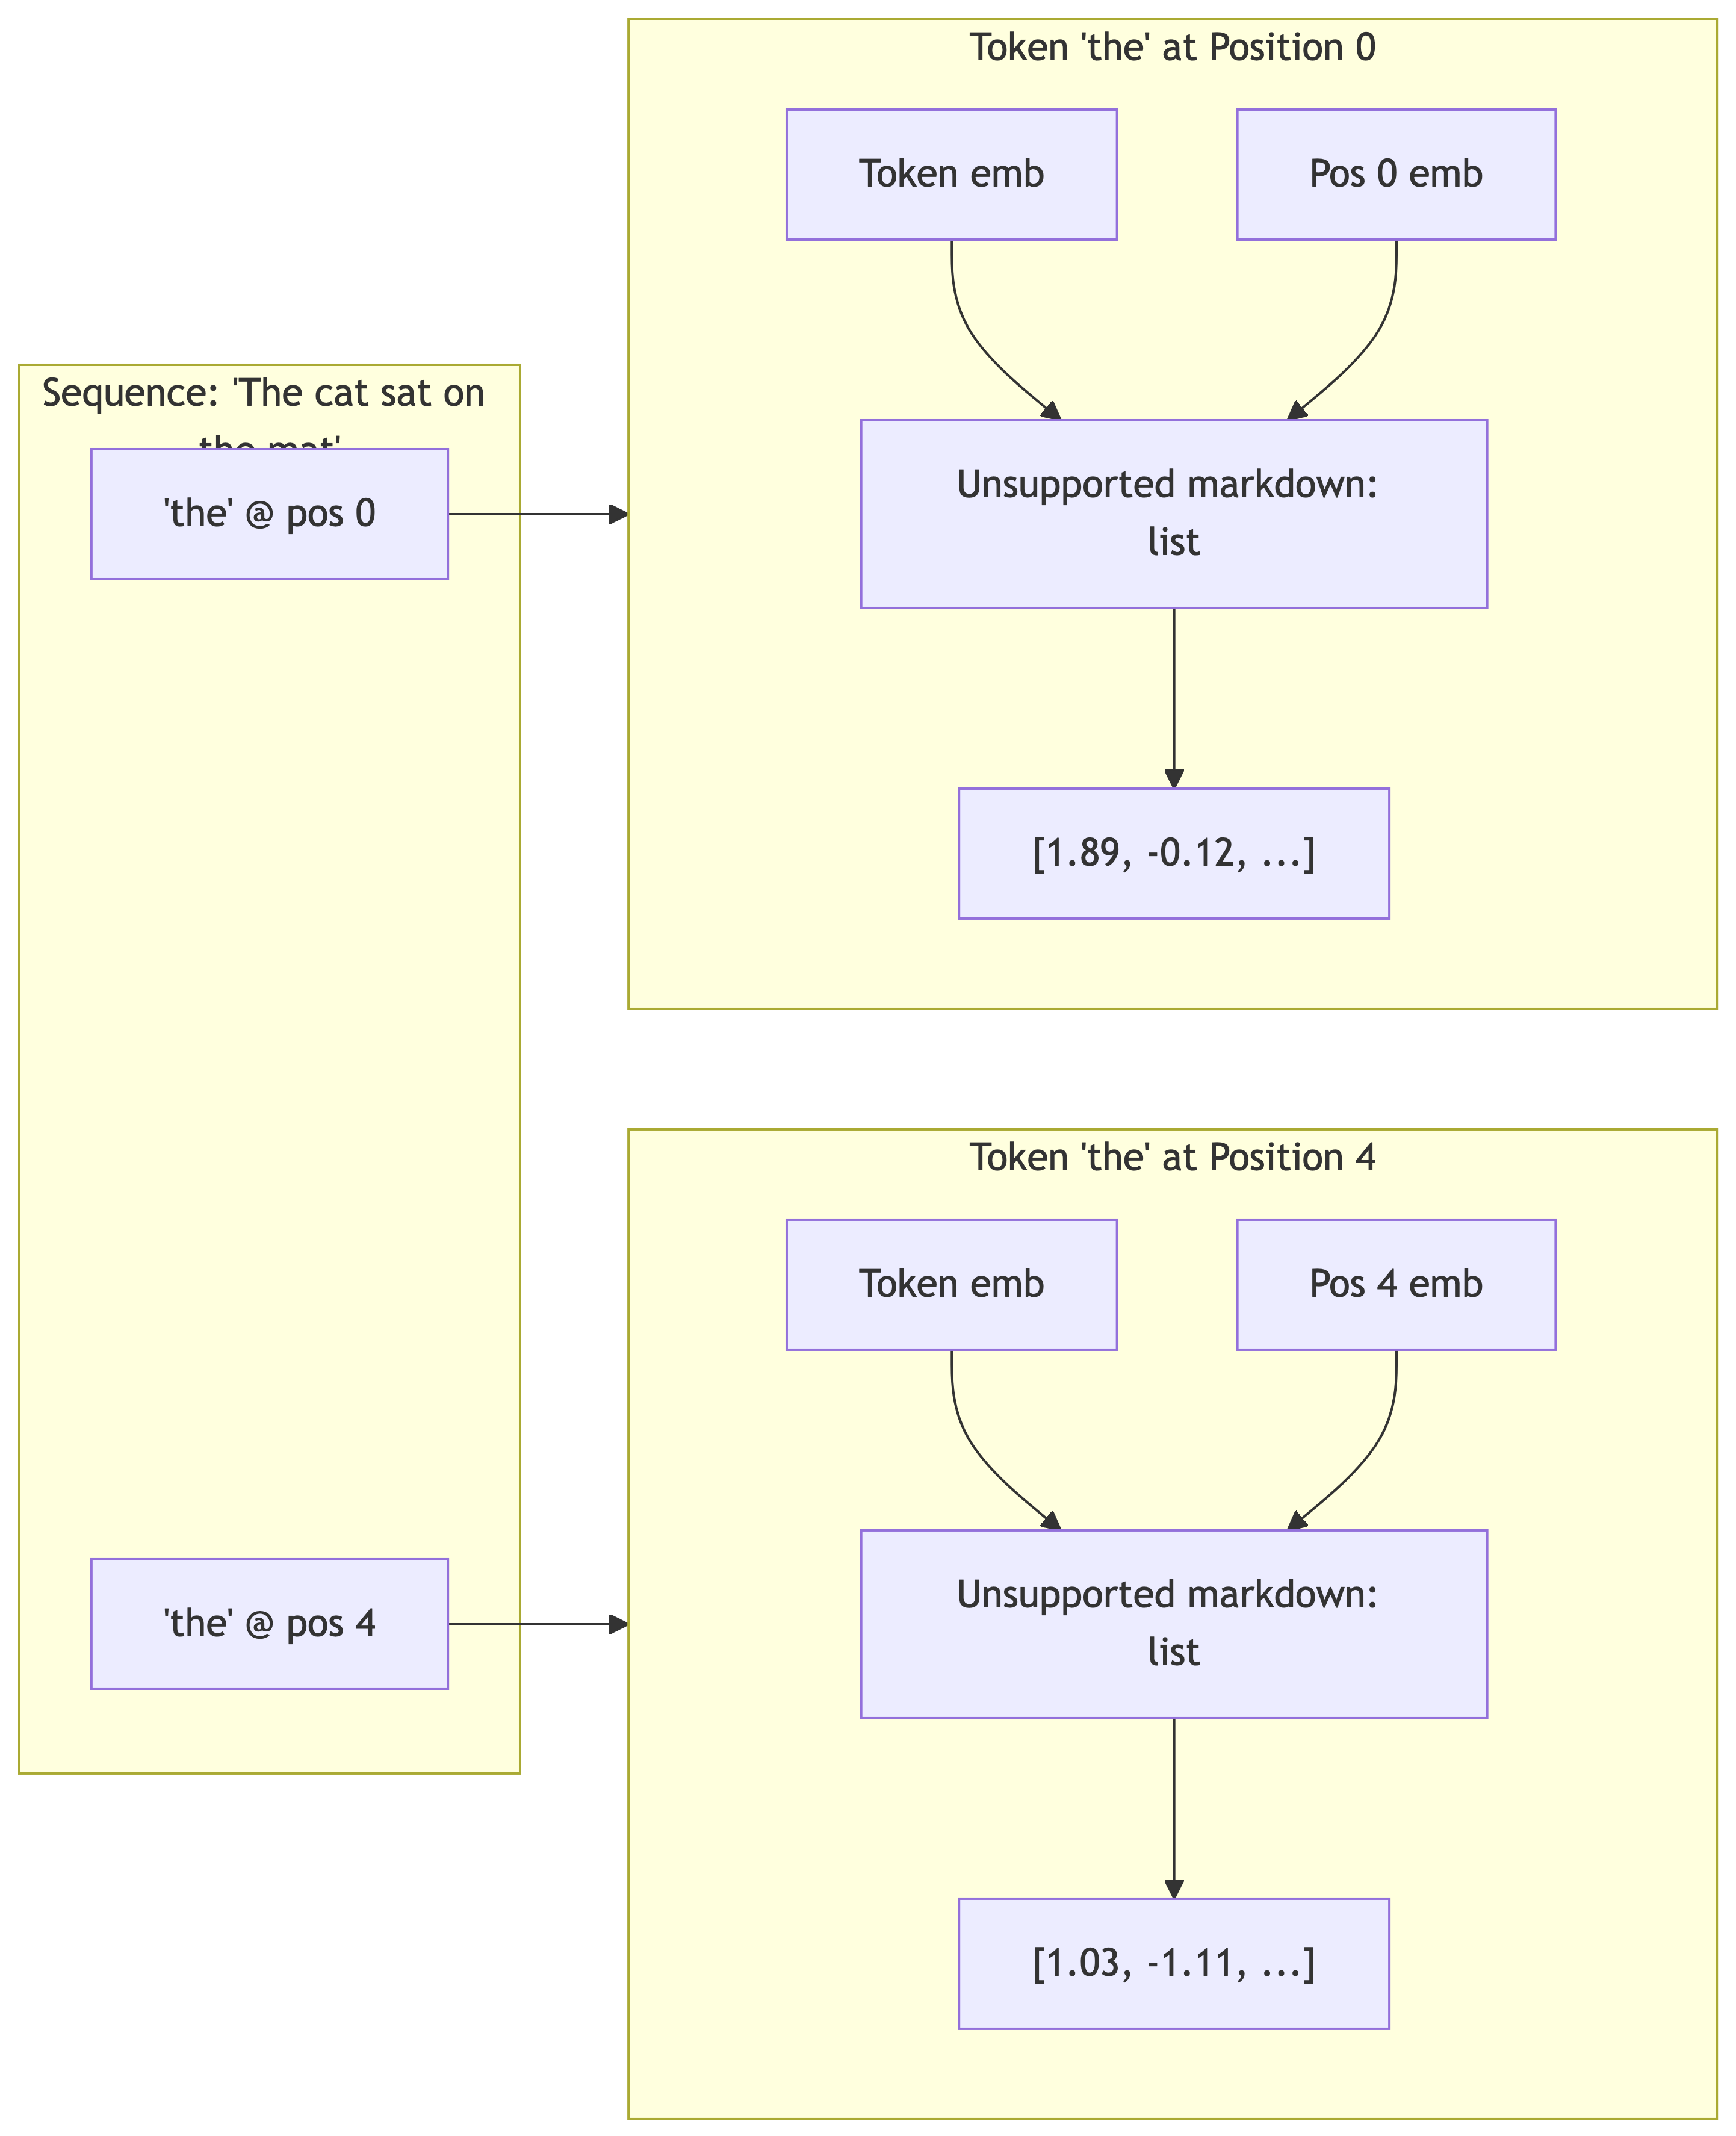

Same token ID produces different final embeddings based on position!

## Code Walkthrough

Let’s explore embeddings interactively:

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.9.1

### Token Embeddings Basics

A token embedding is just a lookup table: token ID -\> vector

In [2]:
# Create a simple token embedding
vocab_size = 100
embed_dim = 32

# nn.Embedding is PyTorch's lookup table
token_emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)

print(f"Vocabulary size: {vocab_size}")
print(f"Embedding dimension: {embed_dim}")
print(f"Total parameters: {vocab_size * embed_dim:,}")
print(f"Embedding table shape: {token_emb.weight.shape}")

Vocabulary size: 100
Embedding dimension: 32
Total parameters: 3,200
Embedding table shape: torch.Size([100, 32])

In [3]:
# Look up embeddings for some tokens
token_ids = torch.tensor([[5, 10, 15, 20]])
embeddings = token_emb(token_ids)

print(f"Input token IDs: {token_ids[0].tolist()}")
print(f"Output shape: {tuple(embeddings.shape)}")
print(f"\nToken 5's embedding (first 8 dims):")
print(f"  {embeddings[0, 0, :8].tolist()}")

Input token IDs: [5, 10, 15, 20]
Output shape: (1, 4, 32)

Token 5's embedding (first 8 dims):
  [0.16217060387134552, 0.8396660089492798, 0.6173838973045349, -0.9519219994544983, -1.4884068965911865, 0.2866053283214569, 0.04093584418296814, 0.7431083917617798]

In [4]:
# Same token always gets the same embedding
e1 = token_emb(torch.tensor([[42]]))
e2 = token_emb(torch.tensor([[42]]))

print(f"Token 42 embedding (call 1): {e1[0, 0, :4].tolist()}")
print(f"Token 42 embedding (call 2): {e2[0, 0, :4].tolist()}")
print(f"Equal: {torch.allclose(e1, e2)}")

Token 42 embedding (call 1): [-0.4772478938102722, -0.18334299325942993, -0.193314328789711, 1.172497272491455]
Token 42 embedding (call 2): [-0.4772478938102722, -0.18334299325942993, -0.193314328789711, 1.172497272491455]
Equal: True

### Sinusoidal Positional Encoding

The original Transformer uses sin/cos functions to encode position. The
key idea is to create a unique “fingerprint” for each position using
waves of different frequencies:

-   **Low-frequency components** (high dimensions): Change slowly across
    positions, capturing coarse position
-   **High-frequency components** (low dimensions): Change rapidly,
    capturing fine-grained position

This is analogous to how Fourier series can represent any periodic
function as a sum of sines and cosines:

In [5]:
import math

def create_sinusoidal_encoding(max_seq_len: int, embed_dim: int) -> torch.Tensor:
    """Create sinusoidal positional encoding matrix."""
    pe = torch.zeros(max_seq_len, embed_dim)
    position = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)

    # Compute div_term: 10000^(2i/d) = exp(2i * -log(10000) / d)
    div_term = torch.exp(
        torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim)
    )

    # Apply sin to even indices, cos to odd indices
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)

    return pe

# Create positional encoding
pe = create_sinusoidal_encoding(max_seq_len=128, embed_dim=64)
print(f"Positional encoding shape: {pe.shape}")

Positional encoding shape: torch.Size([128, 64])

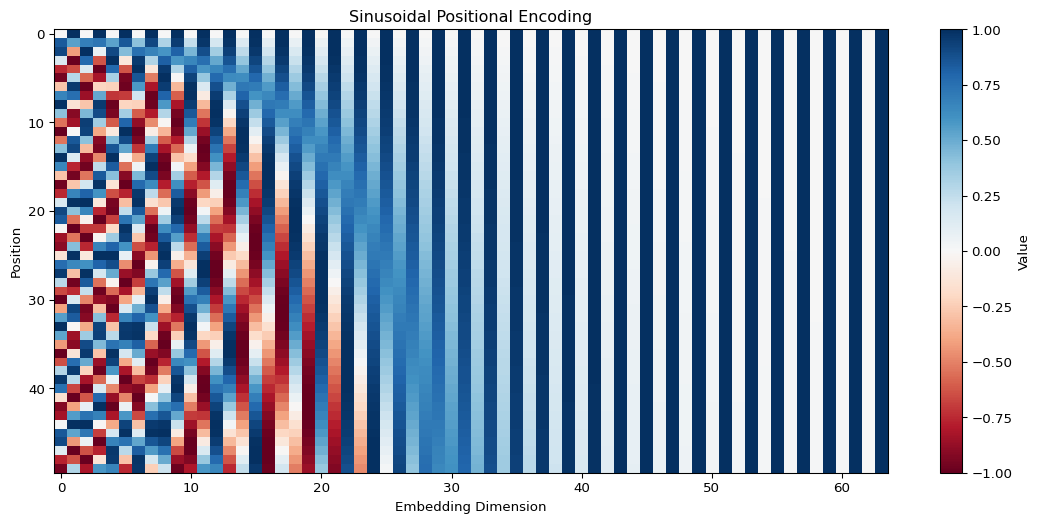

In [6]:
# Visualize as heatmap
plt.figure(figsize=(14, 6))
plt.imshow(pe[:50].numpy(), aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(label='Value')
plt.xlabel('Embedding Dimension')
plt.ylabel('Position')
plt.title('Sinusoidal Positional Encoding')
plt.show()

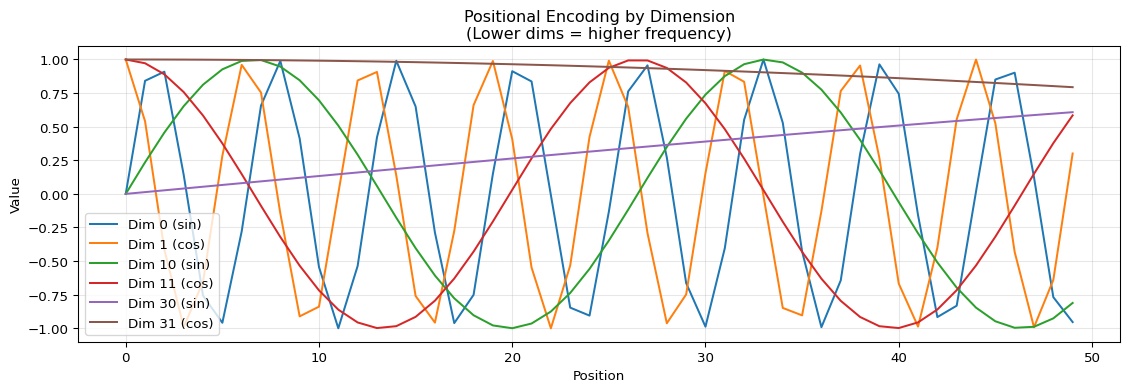

In [7]:
# Plot individual dimensions to see the patterns
plt.figure(figsize=(14, 4))

for dim in [0, 1, 10, 11, 30, 31]:
    plt.plot(pe[:50, dim].numpy(), label=f'Dim {dim} ({"sin" if dim % 2 == 0 else "cos"})')

plt.xlabel('Position')
plt.ylabel('Value')
plt.title('Positional Encoding by Dimension\n(Lower dims = higher frequency)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

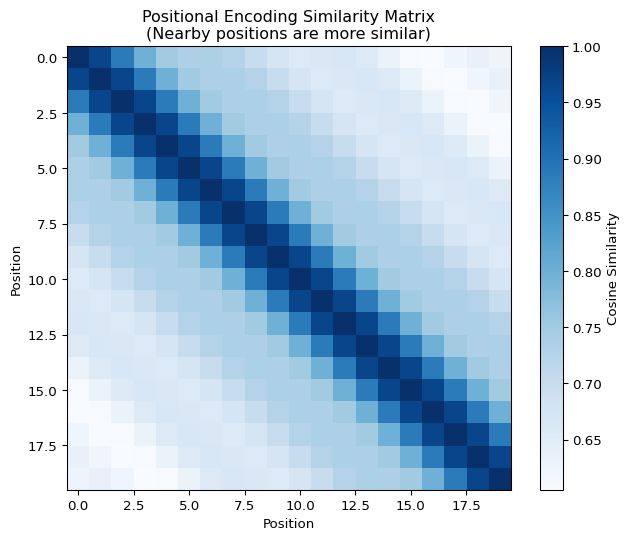

In [8]:
# Compare positions by computing similarity
pe_subset = pe[:20]

# Compute cosine similarity between all position pairs
pe_norm = pe_subset / pe_subset.norm(dim=1, keepdim=True)
similarity = pe_norm @ pe_norm.T

plt.figure(figsize=(8, 6))
plt.imshow(similarity.numpy(), cmap='Blues')
plt.colorbar(label='Cosine Similarity')
plt.xlabel('Position')
plt.ylabel('Position')
plt.title('Positional Encoding Similarity Matrix\n(Nearby positions are more similar)')
plt.show()

Notice that:

1.  **Nearby positions are similar**: Positions 5 and 6 are more similar
    than positions 5 and 15
2.  **The pattern is symmetric**: sim(i, j) = sim(j, i)
3.  **Each position is unique**: No two positions have identical
    encodings

The sinusoidal encoding also has a key mathematical property: for any
fixed offset k, the encoding `PE(pos+k)` can be expressed as a linear
transformation of `PE(pos)`. This helps the model learn relative
positions (e.g., “this token is 3 positions before that token”).

### Combined Transformer Embedding

In practice, we add token embeddings and positional embeddings together.
The implementation in `embeddings.py` includes several important
details:

1.  **Scaling by sqrt(embed_dim)**: Token embeddings are multiplied by
    `sqrt(embed_dim)` before adding positional embeddings. This prevents
    the positional signal from dominating when embed_dim is large (since
    embeddings are typically initialized with small values like
    `std=0.02`).

2.  **Initialization**: Embeddings are initialized from a normal
    distribution with small standard deviation (0.02). This is crucial
    for stable training - large initial values can cause exploding
    gradients.

3.  **Padding token handling**: The embedding for the padding token
    (usually ID 0) is set to zeros and excluded from gradient updates.

4.  **Dropout**: Applied after combining embeddings for regularization.

In [9]:
class TransformerEmbedding(nn.Module):
    """Combined token + positional embedding."""

    def __init__(self, vocab_size: int, embed_dim: int, max_seq_len: int, dropout: float = 0.1):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.position_embedding = nn.Embedding(max_seq_len, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(embed_dim)

    def forward(self, token_ids: torch.Tensor) -> torch.Tensor:
        seq_len = token_ids.shape[1]

        # Get token embeddings and scale
        token_emb = self.token_embedding(token_ids) * self.scale

        # Get positional embeddings
        positions = torch.arange(seq_len, device=token_ids.device)
        pos_emb = self.position_embedding(positions)

        # Combine and apply dropout
        return self.dropout(token_emb + pos_emb)

# Create embedding layer
emb = TransformerEmbedding(
    vocab_size=1000,
    embed_dim=64,
    max_seq_len=128,
    dropout=0.0  # Disable for visualization
)

# Process some tokens
tokens = torch.randint(0, 1000, (1, 10))
output = emb(tokens)

print(f"Input tokens: {tokens[0].tolist()}")
print(f"Output shape: {tuple(output.shape)}")

Input tokens: [306, 964, 423, 493, 780, 742, 39, 913, 470, 867]
Output shape: (1, 10, 64)

In [10]:
# Show that same token at different positions has different embeddings
# Put token 42 at positions 0, 5, and 9
tokens = torch.tensor([[42, 1, 2, 3, 4, 42, 6, 7, 8, 42]])
output = emb(tokens)

# Get the embeddings for token 42 at each position
pos_0 = output[0, 0].detach()
pos_5 = output[0, 5].detach()
pos_9 = output[0, 9].detach()

print("Token 42 at different positions:")
print(f"  Position 0: {pos_0[:4].tolist()}")
print(f"  Position 5: {pos_5[:4].tolist()}")
print(f"  Position 9: {pos_9[:4].tolist()}")
print(f"\nAll different due to positional encoding!")

Token 42 at different positions:
  Position 0: [-3.4360549449920654, 6.142308712005615, -9.62407112121582, 1.1777279376983643]
  Position 5: [-2.3546528816223145, 5.544582366943359, -10.820448875427246, 1.0332472324371338]
  Position 9: [-1.925635814666748, 4.335466384887695, -9.013202667236328, 0.8100054264068604]

All different due to positional encoding!

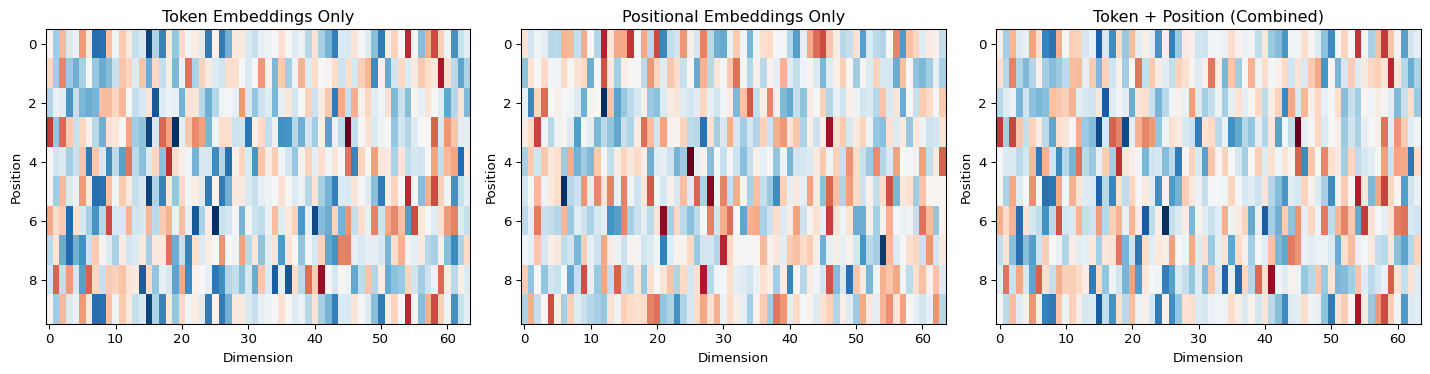

In [11]:
# Visualize the combination
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Token embedding only (without scale for visualization)
token_only = emb.token_embedding(tokens)[0].detach().numpy()
axes[0].imshow(token_only, aspect='auto', cmap='RdBu')
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Position')
axes[0].set_title('Token Embeddings Only')

# Position embedding only
positions = torch.arange(10)
pos_only = emb.position_embedding(positions).detach().numpy()
axes[1].imshow(pos_only, aspect='auto', cmap='RdBu')
axes[1].set_xlabel('Dimension')
axes[1].set_ylabel('Position')
axes[1].set_title('Positional Embeddings Only')

# Combined
combined = output[0].detach().numpy()
axes[2].imshow(combined, aspect='auto', cmap='RdBu')
axes[2].set_xlabel('Dimension')
axes[2].set_ylabel('Position')
axes[2].set_title('Token + Position (Combined)')

plt.tight_layout()
plt.show()

### Embedding Similarity

Embeddings capture meaning - similar tokens should have similar
embeddings:

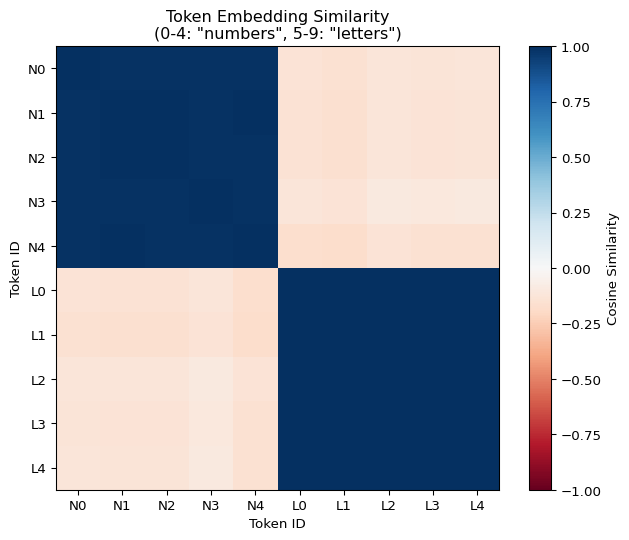

Notice: Numbers (N) are similar to each other, letters (L) are similar to each other,
but numbers and letters are different from each other.

In [12]:
# Let's simulate "training" by manually setting some embeddings to be similar
# In practice, these patterns emerge from training on real text

vocab_size = 20
embed_dim = 16

token_emb = nn.Embedding(vocab_size, embed_dim)

# Manually set some tokens to have similar embeddings
# (simulating what would happen after training on related words)
with torch.no_grad():
    # Tokens 0-4: "numbers" (similar to each other)
    base_number = torch.randn(embed_dim)
    for i in range(5):
        token_emb.weight[i] = base_number + torch.randn(embed_dim) * 0.1

    # Tokens 5-9: "letters" (similar to each other, different from numbers)
    base_letter = torch.randn(embed_dim)
    for i in range(5, 10):
        token_emb.weight[i] = base_letter + torch.randn(embed_dim) * 0.1

# Compute all pairwise similarities
all_embeds = token_emb.weight[:10]
all_embeds_norm = all_embeds / all_embeds.norm(dim=1, keepdim=True)
similarity = (all_embeds_norm @ all_embeds_norm.T).detach().numpy()

plt.figure(figsize=(8, 6))
plt.imshow(similarity, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(label='Cosine Similarity')
plt.xlabel('Token ID')
plt.ylabel('Token ID')
plt.title('Token Embedding Similarity\n(0-4: "numbers", 5-9: "letters")')

# Add labels
labels = ['N0', 'N1', 'N2', 'N3', 'N4', 'L0', 'L1', 'L2', 'L3', 'L4']
plt.xticks(range(10), labels)
plt.yticks(range(10), labels)
plt.show()

print("Notice: Numbers (N) are similar to each other, letters (L) are similar to each other,")
print("but numbers and letters are different from each other.")

### 2D Visualization with PCA

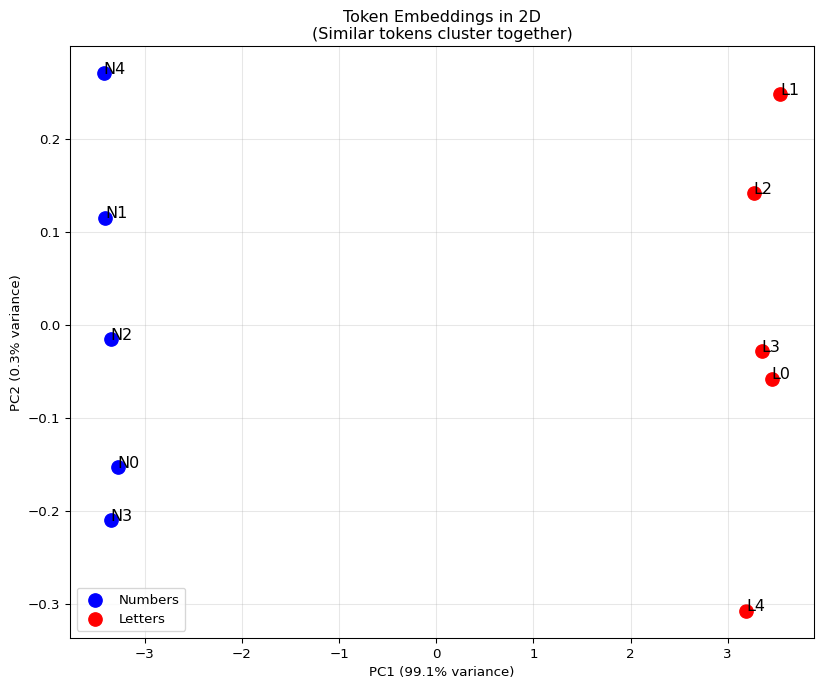

In [13]:
from sklearn.decomposition import PCA

# Get embeddings for all 10 tokens
embeddings = all_embeds.detach().numpy()

# Reduce to 2D
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)

# Plot
plt.figure(figsize=(10, 8))

# Numbers in blue
plt.scatter(emb_2d[:5, 0], emb_2d[:5, 1], c='blue', s=100, label='Numbers')
for i in range(5):
    plt.annotate(f'N{i}', (emb_2d[i, 0], emb_2d[i, 1]), fontsize=12)

# Letters in red
plt.scatter(emb_2d[5:, 0], emb_2d[5:, 1], c='red', s=100, label='Letters')
for i in range(5, 10):
    plt.annotate(f'L{i-5}', (emb_2d[i, 0], emb_2d[i, 1]), fontsize=12)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Token Embeddings in 2D\n(Similar tokens cluster together)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Exercises

### Exercise 1: Compare Learned vs Sinusoidal Positional Embeddings

Learned and sinusoidal embeddings have different tradeoffs:

| Aspect | Learned | Sinusoidal |
|--------------------|-----------------------|------------------------------|
| Training | Updated via backprop | Fixed (no parameters) |
| Extrapolation | Cannot generalize beyond max_seq_len | Can theoretically extrapolate |
| Memory | Adds parameters | Zero parameter overhead |
| Performance | Often slightly better in practice | Good baseline |

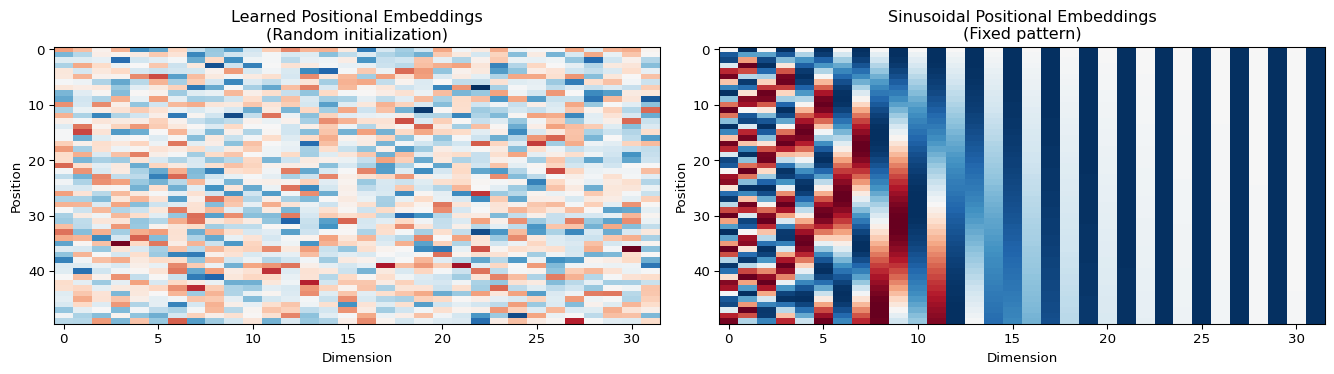

Learned embeddings start random but are trained to capture position.
Sinusoidal embeddings have a fixed pattern that encodes relative positions.

In [14]:
# Compare learned vs sinusoidal positional embeddings

learned = nn.Embedding(50, 32)  # Learned (random initialization)
sinusoidal = create_sinusoidal_encoding(50, 32)  # Fixed pattern

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].imshow(learned.weight.detach().numpy(), aspect='auto', cmap='RdBu')
axes[0].set_title('Learned Positional Embeddings\n(Random initialization)')
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Position')

axes[1].imshow(sinusoidal.numpy(), aspect='auto', cmap='RdBu')
axes[1].set_title('Sinusoidal Positional Embeddings\n(Fixed pattern)')
axes[1].set_xlabel('Dimension')
axes[1].set_ylabel('Position')

plt.tight_layout()
plt.show()

print("Learned embeddings start random but are trained to capture position.")
print("Sinusoidal embeddings have a fixed pattern that encodes relative positions.")

### Exercise 2: Effect of Embedding Dimension

The embedding dimension affects both model capacity and computational
cost. Larger dimensions can represent more nuanced semantic distinctions
but require more memory and computation in every layer of the model.

The `sqrt(embed_dim)` scaling factor is crucial: without it, the
magnitude of embeddings would vary significantly with dimension, since
randomly initialized vectors of higher dimension have larger expected
norms.

In [15]:
# What happens with different embedding dimensions?

for dim in [8, 32, 128, 512]:
    emb = TransformerEmbedding(
        vocab_size=1000,
        embed_dim=dim,
        max_seq_len=128,
        dropout=0.0
    )
    tokens = torch.randint(0, 1000, (1, 32))
    output = emb(tokens)

    # Compute variance of output
    variance = output.var().item()
    print(f"Embed dim {dim:3d}: output variance = {variance:.4f}")

print("\nThe scale factor (sqrt(embed_dim)) helps keep variance stable!")

Embed dim   8: output variance = 8.5881
Embed dim  32: output variance = 35.9062
Embed dim 128: output variance = 126.6794
Embed dim 512: output variance = 513.2229

The scale factor (sqrt(embed_dim)) helps keep variance stable!

### Exercise 3: Memory Usage of Embeddings

Understanding embedding memory is crucial for model sizing. With weight
tying (sharing embeddings between input and output layers), you only pay
this cost once. Without it, you pay twice.

In [16]:
# Memory usage of embeddings

configs = [
    {"vocab": 1000, "dim": 64, "name": "Tiny"},
    {"vocab": 8000, "dim": 256, "name": "Small"},
    {"vocab": 32000, "dim": 512, "name": "Medium"},
    {"vocab": 50000, "dim": 768, "name": "Large (GPT-2)"},
    {"vocab": 100000, "dim": 4096, "name": "Large (LLaMA)"},
]

print("Embedding Table Memory Usage:")
print("=" * 60)

for cfg in configs:
    params = cfg["vocab"] * cfg["dim"]
    memory_mb = params * 4 / (1024 * 1024)  # 4 bytes per float32
    memory_fp16 = memory_mb / 2  # fp16/bf16 halves memory
    print(f"{cfg['name']:15s}: {cfg['vocab']:6d} vocab x {cfg['dim']:4d} dim = "
          f"{params:>12,} params ({memory_mb:>7.1f} MB fp32, {memory_fp16:>6.1f} MB fp16)")

Embedding Table Memory Usage:
Tiny           :   1000 vocab x   64 dim =       64,000 params (    0.2 MB fp32,    0.1 MB fp16)
Small          :   8000 vocab x  256 dim =    2,048,000 params (    7.8 MB fp32,    3.9 MB fp16)
Medium         :  32000 vocab x  512 dim =   16,384,000 params (   62.5 MB fp32,   31.2 MB fp16)
Large (GPT-2)  :  50000 vocab x  768 dim =   38,400,000 params (  146.5 MB fp32,   73.2 MB fp16)
Large (LLaMA)  : 100000 vocab x 4096 dim =  409,600,000 params ( 1562.5 MB fp32,  781.2 MB fp16)

Note: Modern models typically use fp16 or bf16, which halves the memory
requirement. Quantization (int8, int4) can reduce it further.

## Using the Module’s Embeddings

The `embeddings.py` file contains production-ready embedding classes:

In [17]:
from embeddings import (
    TokenEmbedding,
    LearnedPositionalEmbedding,
    SinusoidalPositionalEmbedding,
    TransformerEmbedding as ModuleTransformerEmbedding,
    demonstrate_embeddings
)

# Run the demonstration
demo_emb = demonstrate_embeddings(
    vocab_size=100,
    embed_dim=32,
    seq_len=8,
    verbose=True
)

EMBEDDING DEMONSTRATION

Created TransformerEmbedding:
  Vocab size: 100
  Embed dim: 32
  Max seq len: 128

Input token IDs (batch=2, seq=8):
  [32, 69, 88, 74, 53, 65, 73, 79]
  [61, 48, 98, 69, 99, 78, 70, 79]

Output shape: (2, 8, 32)
  (batch_size, seq_len, embed_dim)

First token's embedding (first 8 dims):
  [-0.056191641837358475, 0.05961769074201584, 0.1283511519432068, -0.05212362855672836, -0.07741592824459076, 0.012629510834813118, 0.15427573025226593, 0.09208652377128601]

Token embedding lookup is consistent:
  Token 5 (first call):  [0.006873161531984806, 0.051817744970321655, -0.013288861140608788, 0.002104131504893303]
  Token 5 (second call): [0.006873161531984806, 0.051817744970321655, -0.013288861140608788, 0.002104131504893303]
  Equal: True

## Summary

Key takeaways:

1.  **Token embeddings** are lookup tables that convert token IDs to
    vectors
2.  **Positional embeddings** add information about where tokens are in
    the sequence
3.  **Sinusoidal** positional embeddings use fixed sin/cos patterns - no
    parameters, can theoretically extrapolate
4.  **Learned** positional embeddings are trained like any other
    parameter - often slightly better in practice
5.  **Modern approaches** (RoPE, ALiBi) handle position differently and
    extrapolate better to long sequences
6.  **Similar tokens** end up with similar embeddings after training -
    capturing semantic relationships
7.  **Scaling by sqrt(embed_dim)** helps maintain stable gradients when
    dimensions vary
8.  **Weight tying** between input embeddings and output layer is common
    and reduces parameters

### Common Pitfalls

-   **Forgetting the sqrt scale**: Without it, positional embeddings can
    dominate or be ignored depending on embed_dim
-   **Exceeding max_seq_len**: Learned positional embeddings fail hard
    on longer sequences than training
-   **Ignoring padding**: Padding tokens should be zero vectors and
    excluded from gradients
-   **Poor initialization**: Large initial values cause training
    instability; use small std (0.01-0.02)

## Going Deeper

-   [Word2Vec](https://arxiv.org/abs/1301.3781) - Original word
    embeddings paper (Mikolov et al., 2013)
-   [Attention Is All You Need](https://arxiv.org/abs/1706.03762) -
    Section 3.5 on positional encoding
-   [RoFormer: Rotary Position Embedding
    (RoPE)](https://arxiv.org/abs/2104.09864) - Used in LLaMA, Mistral
-   [ALiBi: Train Short, Test Long](https://arxiv.org/abs/2108.12409) -
    Position as attention bias
-   [Using the Output Embedding to Improve Language
    Models](https://arxiv.org/abs/1608.05859) - Weight tying paper

## What’s Next

In [Module 05: Attention](../m05_attention/lesson.qmd), we’ll learn the
core mechanism that allows tokens to “look at” each other. Embeddings
are the input to attention - the vectors that get attended to. The
positional information encoded here becomes crucial when attention
computes relationships between tokens.